# TESS Light Curve Analysis
This notebook explores TESS (Transiting Exoplanet Survey Satellite) light curve files (LCF) for a given target across three sectors (43, 44, 45). TESS light curves contain time-series photometry extracted from the target pixel files. Two primary flux measurements are provided:
- **SAP_FLUX**: Simple Aperture Photometry – the raw flux summed over the optimal aperture pixels.
- **PDCSAP_FLUX**: Pre‑search Data Conditioning SAP – the SAP flux after systematic noise correction (e.g., spacecraft motion, focus changes). PDCSAP is generally preferred for planet searches.

We will load the data, convert the time to absolute Barycentric Julian Date (BJD), apply quality flags to remove bad measurements, and visualize the light curves.

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
%matplotlib widget

In [21]:
# Plot style
import matplotlib as mpl
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["EB Garamond", "Georgia", "Times New Roman"],
    # ---- Sizes ----
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "axes.labelweight": "light",  # x/y labels
    "font.weight": "light",
    # ---- Axes/ticks style like the PDF ----
    "axes.edgecolor": "0.2",
    "axes.linewidth": 0.7,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.minor.size": 2,
    "ytick.minor.size": 2,
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    "xtick.minor.width": 0.4,
    "ytick.minor.width": 0.4,

    "axes.grid": False,
    "axes.labelcolor": "0.2",
    "xtick.color": "0.2",
    "ytick.color": "0.2",
    "text.color": "0.2",
})


%matplotlib widget

In [24]:
# paths to the TESS light curve files for Sectors 43, 44, and 45. 
# These are FITS files containing a single binary table HDU with the time series data.
sector43_lcf = '43_lc.fits'
sector44_lcf = '44_lc.fits'
sector45_lcf = '45_lc.fits'

In [25]:
lchdu43 = fits.open(sector43_lcf)
lchdu44 = fits.open(sector44_lcf)
lchdu45 = fits.open(sector45_lcf)

In [8]:
sap_flux_43 = lchdu43[1].data['SAP_FLUX']
sap_flux_error_43 = lchdu43[1].data['SAP_FLUX_ERR']
pdcsap_flux_43 = lchdu43[1].data['PDCSAP_FLUX']
pdcsap_flux_error_43 = lchdu43[1].data['PDCSAP_FLUX_ERR']
quality_bitmask_43 = lchdu43[1].data['QUALITY']

In [9]:
sap_flux_44 = lchdu44[1].data['SAP_FLUX']
sap_flux_error_44 = lchdu44[1].data['SAP_FLUX_ERR']
pdcsap_flux_44 = lchdu44[1].data['PDCSAP_FLUX']
pdcsap_flux_error_44 = lchdu44[1].data['PDCSAP_FLUX_ERR']
quality_bitmask_44 = lchdu44[1].data['QUALITY']

In [10]:
sap_flux_45 = lchdu45[1].data['SAP_FLUX']
sap_flux_error_45 = lchdu45[1].data['SAP_FLUX_ERR']
pdcsap_flux_45 = lchdu45[1].data['PDCSAP_FLUX']
pdcsap_flux_error_45 = lchdu45[1].data['PDCSAP_FLUX_ERR']
quality_bitmask_45 = lchdu45[1].data['QUALITY']

In [11]:
print('BJDREFI header value for sector 43:  {1:d}, comment: {0:s}'.format(lchdu43[1].header.comments['BJDREFI'], lchdu43[1].header['BJDREFI']))
print('BJDREFF header value for sector 43: {1:f}, comment: {0:s}'.format(lchdu43[1].header.comments['BJDREFF'], lchdu43[1].header['BJDREFF']))
print('--------------')
print('BJDREFI header value for sector 44:  {1:d}, comment: {0:s}'.format(lchdu44[1].header.comments['BJDREFI'], lchdu44[1].header['BJDREFI']))
print('BJDREFF header value for sector 44: {1:f}, comment: {0:s}'.format(lchdu44[1].header.comments['BJDREFF'], lchdu44[1].header['BJDREFF']))
print('--------------')
print('BJDREFI header value for sector 45:  {1:d}, comment: {0:s}'.format(lchdu45[1].header.comments['BJDREFI'], lchdu45[1].header['BJDREFI']))
print('BJDREFF header value for sector 45: {1:f}, comment: {0:s}'.format(lchdu45[1].header.comments['BJDREFF'], lchdu45[1].header['BJDREFF']))

BJDREFI header value for sector 43:  2457000, comment: integer part of BTJD reference date
BJDREFF header value for sector 43: 0.000000, comment: fraction of the day in BTJD reference date
--------------
BJDREFI header value for sector 44:  2457000, comment: integer part of BTJD reference date
BJDREFF header value for sector 44: 0.000000, comment: fraction of the day in BTJD reference date
--------------
BJDREFI header value for sector 45:  2457000, comment: integer part of BTJD reference date
BJDREFF header value for sector 45: 0.000000, comment: fraction of the day in BTJD reference date


In [12]:
time_array_43 = lchdu43[1].data['TIME'] + lchdu43[1].header['BJDREFI'] +  lchdu43[1].header['BJDREFF']

time_array_44 = lchdu44[1].data['TIME'] + lchdu44[1].header['BJDREFI'] +  lchdu44[1].header['BJDREFF']

time_array_45 = lchdu45[1].data['TIME'] + lchdu45[1].header['BJDREFI'] +  lchdu45[1].header['BJDREFF']

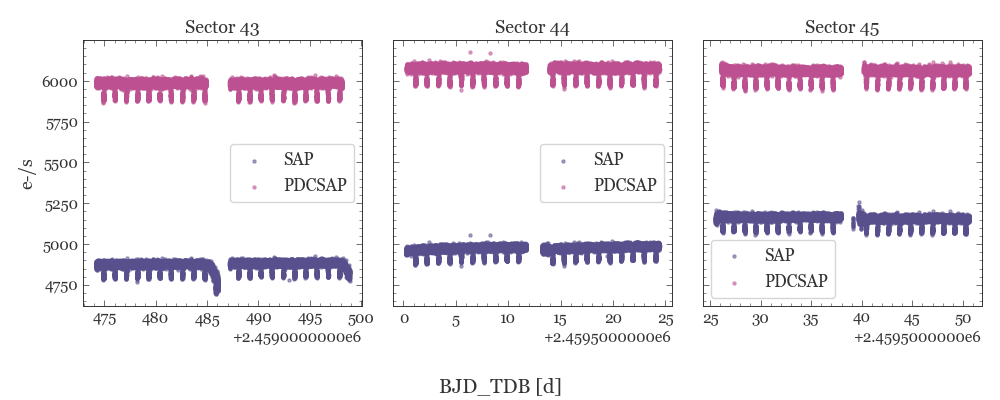

In [13]:
fig, ax = plt.subplots(1, 3, figsize=(10, 4), sharey=True)

# Plot for Sector 43
ax[0].scatter(time_array_43, sap_flux_43, c='#58508d', s=5, alpha=0.5, label='SAP')
ax[0].scatter(time_array_43, pdcsap_flux_43, c='#bc5090', s=5, alpha=0.5, label='PDCSAP')
ax[0].set_ylabel('e-/s')
ax[0].legend()
ax[0].set_title('Sector 43')

# Plot for Sector 44
ax[1].scatter(time_array_44, sap_flux_44, c='#58508d', s=5, alpha=0.5, label='SAP')
ax[1].scatter(time_array_44, pdcsap_flux_44, c='#bc5090', s=5, alpha=0.5, label='PDCSAP')
ax[1].legend()
ax[1].set_title('Sector 44')

# Plot for Sector 45
ax[2].scatter(time_array_45, sap_flux_45, c='#58508d', s=5, alpha=0.5, label='SAP')
ax[2].scatter(time_array_45, pdcsap_flux_45, c='#bc5090', s=5, alpha=0.5, label='PDCSAP')
ax[2].legend()
ax[2].set_title('Sector 45')

# Single shared x-label for the whole figure
fig.supxlabel('BJD_TDB [d]')

plt.tight_layout()
plt.show()

In [14]:
print('Sector 43')
print('Number of BJD epochs   :', np.shape(time_array_43))
print('Number of SAP epochs   :', np.shape(sap_flux_43))
print('Number of PDCSAP epochs:', np.shape(pdcsap_flux_43))
print('-----------')
print('Sector 44')
print('Number of BJD epochs   :', np.shape(time_array_44))
print('Number of SAP epochs   :', np.shape(sap_flux_44))
print('Number of PDCSAP epochs:', np.shape(pdcsap_flux_44))
print('-----------')
print('Sector 45')
print('Number of BJD epochs   :', np.shape(time_array_45))
print('Number of SAP epochs   :', np.shape(sap_flux_45))
print('Number of PDCSAP epochs:', np.shape(pdcsap_flux_45))
print('-----------')

Sector 43
Number of BJD epochs   : (17804,)
Number of SAP epochs   : (17804,)
Number of PDCSAP epochs: (17804,)
-----------
Sector 44
Number of BJD epochs   : (17466,)
Number of SAP epochs   : (17466,)
Number of PDCSAP epochs: (17466,)
-----------
Sector 45
Number of BJD epochs   : (18089,)
Number of SAP epochs   : (18089,)
Number of PDCSAP epochs: (18089,)
-----------


In [15]:
finite_selection_43 = np.isfinite(pdcsap_flux_43)
finite_selection_44 = np.isfinite(pdcsap_flux_44)
finite_selection_45 = np.isfinite(pdcsap_flux_45)

In [16]:
conservative_selection_43 =  ~(quality_bitmask_43 > 0) & finite_selection_43
conservative_selection_44 =  ~(quality_bitmask_44 > 0) & finite_selection_44
conservative_selection_45 =  ~(quality_bitmask_45 > 0) & finite_selection_45

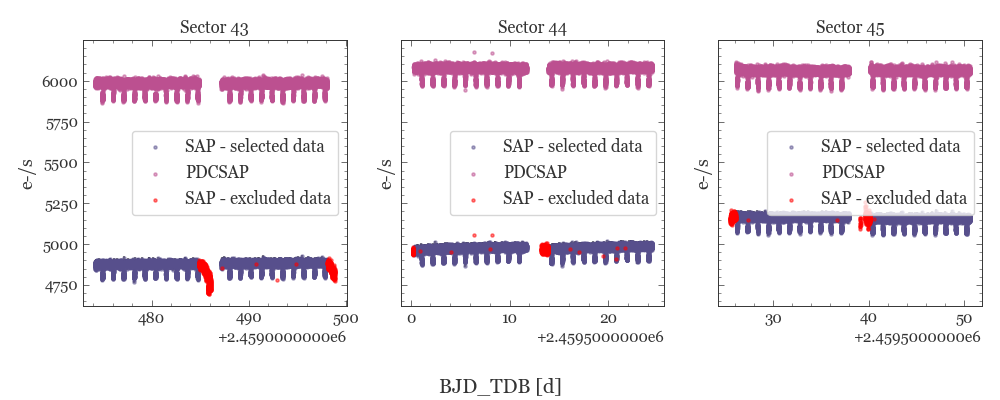

In [17]:
fig, ax = plt.subplots(1, 3, figsize=(10, 4), sharey=True)

# Data for each sector
sectors = [
    (time_array_43, sap_flux_43, sap_flux_error_43, pdcsap_flux_43, conservative_selection_43, "Sector 43"),
    (time_array_44, sap_flux_44, sap_flux_error_44, pdcsap_flux_44, conservative_selection_44, "Sector 44"),
    (time_array_45, sap_flux_45, sap_flux_error_45, pdcsap_flux_45, conservative_selection_45, "Sector 45")
]

# Plot for each sector
for i, (time_array, sap_flux, sap_flux_error, pdcsap_flux, conservative_selection, title) in enumerate(sectors):
    ax[i].scatter(time_array[conservative_selection], sap_flux[conservative_selection],
                  s=5, c='#58508d', alpha=0.5, label='SAP - selected data')
    ax[i].scatter(time_array, pdcsap_flux, s=5, c='#bc5090', alpha=0.5, label='PDCSAP')
    ax[i].scatter(time_array[~conservative_selection], sap_flux[~conservative_selection],
                  s=5, c='r', alpha=0.5, label='SAP - excluded data')
    ax[i].errorbar(time_array[conservative_selection], sap_flux[conservative_selection],
                   yerr=sap_flux_error[conservative_selection], fmt=' ', alpha=0.5,
                   ecolor='k', zorder=-1)
    # Remove individual xlabel – we'll use one for the whole figure
    ax[i].set_ylabel('e-/s')
    ax[i].set_title(f"{title}", fontsize=12)
    ax[i].legend()

# Single shared x-label
fig.supxlabel('BJD_TDB [d]')

plt.tight_layout()
plt.show()

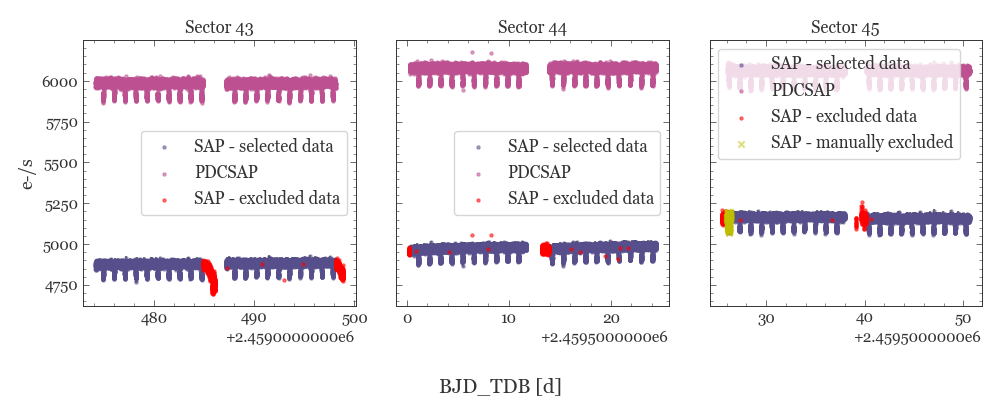

In [18]:
final_selection_43 = conservative_selection_43
final_selection_44 = conservative_selection_44
final_selection_45 = conservative_selection_45 & (time_array_45 > 2459526.394)


fig, ax = plt.subplots(1, 3, figsize=(10, 4), sharey=True)

# Plot for Sector 43
ax[0].scatter(time_array_43[conservative_selection_43], sap_flux_43[conservative_selection_43], s=5, c='#58508d', alpha=0.5, label='SAP - selected data')
ax[0].scatter(time_array_43, pdcsap_flux_43, s=5, c='#bc5090', alpha=0.5, label='PDCSAP')
ax[0].scatter(time_array_43[~conservative_selection_43], sap_flux_43[~conservative_selection_43], s=5, c='r', alpha=0.5, label='SAP - excluded data')
#ax[0].scatter(time_array_43[~final_selection_43 & conservative_selection_43], sap_flux_43[~final_selection_43 & conservative_selection_43], s=2, c='y', marker='x', alpha=0.5, label='SAP - manually excluded')
ax[0].errorbar(time_array_43[conservative_selection_43], sap_flux_43[conservative_selection_43], yerr=sap_flux_error_43[conservative_selection_43], fmt=' ', alpha=0.5, ecolor='k', zorder=-1)
ax[0].set_ylabel('e-/s')
ax[0].set_title("Sector 43", fontsize=12)
ax[0].legend()

# Plot for Sector 44
ax[1].scatter(time_array_44[conservative_selection_44], sap_flux_44[conservative_selection_44], s=5, c='#58508d', alpha=0.5, label='SAP - selected data')
ax[1].scatter(time_array_44, pdcsap_flux_44, s=5, c='#bc5090', alpha=0.5, label='PDCSAP')
ax[1].scatter(time_array_44[~conservative_selection_44], sap_flux_44[~conservative_selection_44], s=5, c='r', alpha=0.5, label='SAP - excluded data')
#ax[1].scatter(time_array_44[~final_selection_44 & conservative_selection_44], sap_flux_44[~final_selection_44 & conservative_selection_44], s=20, c='y', marker='x', alpha=0.5, label='SAP - manually excluded')
ax[1].errorbar(time_array_44[conservative_selection_44], sap_flux_44[conservative_selection_44], yerr=sap_flux_error_44[conservative_selection_44], fmt=' ', alpha=0.5, ecolor='k', zorder=-1)
ax[1].set_title("Sector 44", fontsize=12)
ax[1].legend()

# Plot for Sector 45
ax[2].scatter(time_array_45[conservative_selection_45], sap_flux_45[conservative_selection_45], s=5,  c='#58508d', alpha=0.5, label='SAP - selected data')
ax[2].scatter(time_array_45, pdcsap_flux_45, s=5, c='#bc5090', alpha=0.5, label='PDCSAP')
ax[2].scatter(time_array_45[~conservative_selection_45], sap_flux_45[~conservative_selection_45], s=5, c='r', alpha=0.5, label='SAP - excluded data')
ax[2].scatter(time_array_45[~final_selection_45 & conservative_selection_45], sap_flux_45[~final_selection_45 & conservative_selection_45], s=20, c='y', marker='x', alpha=0.5, label='SAP - manually excluded')
ax[2].errorbar(time_array_45[conservative_selection_45], sap_flux_45[conservative_selection_45], yerr=sap_flux_error_45[conservative_selection_45], fmt=' ', alpha=0.5, ecolor='k', zorder=-1)
ax[2].set_title("Sector 45", fontsize=12)
ax[2].legend()
fig.supxlabel('BJD_TDB [d]')

plt.tight_layout()
plt.show()



In [19]:
import pickle

# Dictionary for Sector 43
sector43_dictionary = {
    'time': time_array_43[final_selection_43],
    'sap_flux': sap_flux_43[final_selection_43],
    'sap_flux_error': sap_flux_error_43[final_selection_43],
    'pdcsap_flux': pdcsap_flux_43[final_selection_43],
    'pdcsap_flux_error': sap_flux_error_43[final_selection_43]  # Replace with correct PDCSAP error if available
}

pickle.dump(sector43_dictionary, 
            open('WASP_TESS_sector43_selected.p', 'wb'))

# Dictionary for Sector 44
sector44_dictionary = {
    'time': time_array_44[final_selection_44],
    'sap_flux': sap_flux_44[final_selection_44],
    'sap_flux_error': sap_flux_error_44[final_selection_44],
    'pdcsap_flux': pdcsap_flux_44[final_selection_44],
    'pdcsap_flux_error': sap_flux_error_44[final_selection_44]  # Replace with correct PDCSAP error if available
}

pickle.dump(sector44_dictionary, 
            open('WASP_TESS_sector44_selected.p', 'wb'))

# Dictionary for Sector 45
sector45_dictionary = {
    'time': time_array_45[final_selection_45],
    'sap_flux': sap_flux_45[final_selection_45],
    'sap_flux_error': sap_flux_error_45[final_selection_45],
    'pdcsap_flux': pdcsap_flux_45[final_selection_45],
    'pdcsap_flux_error': sap_flux_error_45[final_selection_45]  # Replace with correct PDCSAP error if available
}

pickle.dump(sector45_dictionary, 
            open('WASP_TESS_sector45_selected.p', 'wb'))
